<a href="https://colab.research.google.com/github/ANCAMABEBA/CapstoneProject/blob/main/LoanDefaultModelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project — Loan Default Risk Modeling

## Business Understanding

Lending institutions face material financial losses when borrowers default on their loans. A predictive model that identifies high-risk applicants can support better underwriting decisions, risk-based pricing, and portfolio monitoring.

The objective of this project is to build and compare multiple machine learning models that predict the probability of loan default using borrower, loan, and credit-related characteristics from Lending Club loan data.

Because missed defaults are costly, this project prioritizes **recall** as the primary evaluation metric. In other words, the modeling strategy emphasizes identifying as many risky loans as possible, while still monitoring precision, F1-score, and ROC-AUC.

## Project Goals

- Clean and prepare the Lending Club dataset
- Perform exploratory data analysis (EDA)
- Engineer risk-relevant features
- Build multiple classification models
- Address class imbalance
- Use cross-validation and hyperparameter tuning
- Prepare candidate models for final evaluation in a separate notebook

## Modeling Assumption

This project defines default using the following loan statuses:

- **Default = 1**:
  - `charged_off`
  - `default`
  - `late_(31-120_days)`
  - `late_(16-30_days)`

- **Non-default = 0**:
  - `fully_paid`
  - `current`

This treatment of `current` loans as non-default is a simplifying assumption for this academic project. In reality, some current loans may still default later, so this assumption should be considered a limitation of the analysis.

In [1]:
# Install additional libraries in Colab
!pip -q install xgboost lightgbm imbalanced-learn

# 1. Import Libraries

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    make_scorer
)

from scipy.stats import loguniform

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42

# 2. Load Data

In [4]:
# Update path if needed
file_path = "/content/loan.csv"

df = pd.read_csv(file_path, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (511859, 74)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-1985,1.0,NaN,NaN,3.0,0.0,13648.0,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-2015,171.62,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-2011,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-1999,5.0,NaN,NaN,3.0,0.0,1687.0,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-2013,119.66,NaN,Sep-2013,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-2001,2.0,NaN,NaN,2.0,0.0,2956.0,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-2014,649.91,NaN,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-2011,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-1996,1.0,35.0,NaN,10.0,0.0,5598.0,21.0,37.0,f,0.0,0.0,12226.302212,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-2015,357.48,NaN,Jan-2015,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-2011,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-1996,0.0,38.0,NaN,15.0,0.0,27783.0,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-2016,67.79,Feb-2016,Jan-2016,0.0,NaN,1.0,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 3. Initial Inspection

In [5]:
print("Dataset shape:", df.shape)
print("\nColumn count:", len(df.columns))
print("\nFirst 10 columns:", df.columns[:10].tolist())

Dataset shape: (511859, 74)

Column count: 74

First 10 columns: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511859 entries, 0 to 511858
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           511859 non-null  int64  
 1   member_id                    511859 non-null  int64  
 2   loan_amnt                    511859 non-null  float64
 3   funded_amnt                  511859 non-null  float64
 4   funded_amnt_inv              511859 non-null  float64
 5   term                         511859 non-null  object 
 6   int_rate                     511859 non-null  float64
 7   installment                  511859 non-null  float64
 8   grade                        511859 non-null  object 
 9   sub_grade                    511859 non-null  object 
 10  emp_title                    481542 non-null  object 
 11  emp_length                   488127 non-null  object 
 12  home_ownership               511859 non-null  object 
 13 

In [7]:
df.isna().mean().sort_values(ascending=False).head(20)

,0
dti_joint,0.999553
annual_inc_joint,0.999551
verification_status_joint,0.999551
il_util,0.963629
mths_since_rcnt_il,0.959344
inq_fi,0.958246
open_rv_24m,0.958246
open_acc_6m,0.958246
all_util,0.958246
inq_last_12m,0.958246


# 4. Data Cleaning

This section removes identifier and leakage columns, standardizes formats, handles missing values, and prepares the data for modeling.

In [8]:
# Drop columns that are identifiers, links, high-cardinality free text, or clear leakage
cols_to_drop = [
    'id', 'member_id', 'url',
    'emp_title', 'desc', 'title',

    # clear post-origination / leakage variables
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee',
    'last_pymnt_amnt',
    'next_pymnt_d'
]

existing_drop_cols = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=existing_drop_cols)

print("Remaining shape after dropping selected columns:", df.shape)

Remaining shape after dropping selected columns: (511859, 57)


In [9]:
# Fix percentage fields
for col in ['int_rate', 'revol_util']:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('%', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert term to numeric months
if 'term' in df.columns:
    df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)

# Employment length mapping
emp_length_map = {
    '< 1 year': 0.5,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

if 'emp_length' in df.columns:
    df['emp_length'] = df['emp_length'].map(emp_length_map)

In [10]:
# Parse dates
date_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d']

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%b-%Y', errors='coerce')

# Standardize categorical text
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace('nan', np.nan)
    )

# Fill missing categorical values with 'unknown'
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna('unknown')

In [11]:
# Normalize selected categorical values
if 'home_ownership' in df.columns:
    df['home_ownership'] = df['home_ownership'].replace({
        'none': 'rent',
        'any': 'other'
    })

if 'loan_status' in df.columns:
    df['loan_status'] = df['loan_status'].str.replace(' ', '_', regex=False)

In [12]:
# Drop columns with very high missingness (> 70%)
missing_pct = df.isna().mean()
high_missing_cols = missing_pct[missing_pct > 0.70].index.tolist()

df = df.drop(columns=high_missing_cols)

print("Dropped high-missing columns:", len(high_missing_cols))
print("Shape after dropping high-missing columns:", df.shape)

Dropped high-missing columns: 18
Shape after dropping high-missing columns: (511859, 39)


In [13]:
# Basic data-quality filters
if 'annual_inc' in df.columns:
    df = df[df['annual_inc'] > 0]

if 'dti' in df.columns:
    df = df[(df['dti'] >= 0) & (df['dti'] <= 100)]

if 'revol_util' in df.columns:
    df = df[(df['revol_util'].isna()) | ((df['revol_util'] >= 0) & (df['revol_util'] <= 150))]

df = df.drop_duplicates()

print("Shape after data-quality filtering:", df.shape)

Shape after data-quality filtering: (511842, 39)


# 5. Target Variable Definition

In [14]:
default_map = {
    'charged_off': 1,
    'default': 1,
    'late_(31-120_days)': 1,
    'late_(16-30_days)': 1,
    'fully_paid': 0,
    'current': 0
}

df['default_flag'] = df['loan_status'].map(default_map)

# Keep only mapped observations
df = df.dropna(subset=['default_flag']).copy()
df['default_flag'] = df['default_flag'].astype(int)

print(df['default_flag'].value_counts())
print("\nDefault rate:", round(df['default_flag'].mean(), 4))

default_flag
0    445823
1     51458
Name: count, dtype: int64

Default rate: 0.1035


# 6. Exploratory Data Analysis (EDA)

This section reviews the target distribution and key relationships between borrower characteristics and loan default behavior.

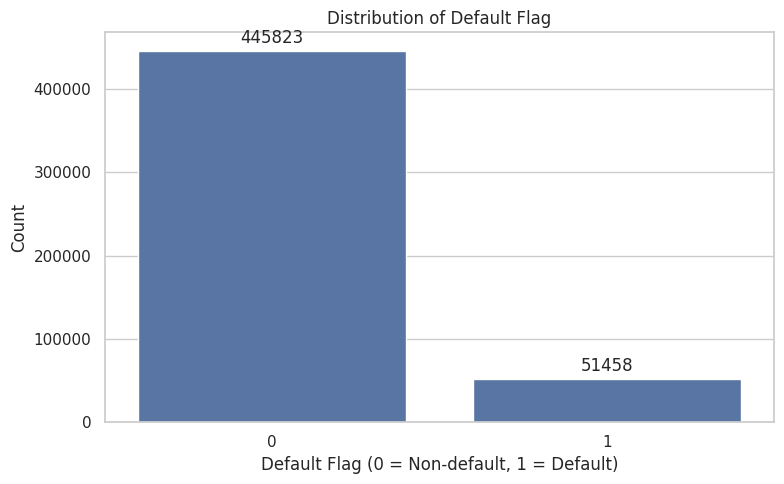

In [15]:
# Target distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='default_flag', ax=ax)
ax.set_title('Distribution of Default Flag')
ax.set_xlabel('Default Flag (0 = Non-default, 1 = Default)')
ax.set_ylabel('Count')
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

In [16]:
# Default rate percentage
default_rate = df['default_flag'].mean() * 100
print(f"Default rate: {default_rate:.2f}%")

Default rate: 10.35%


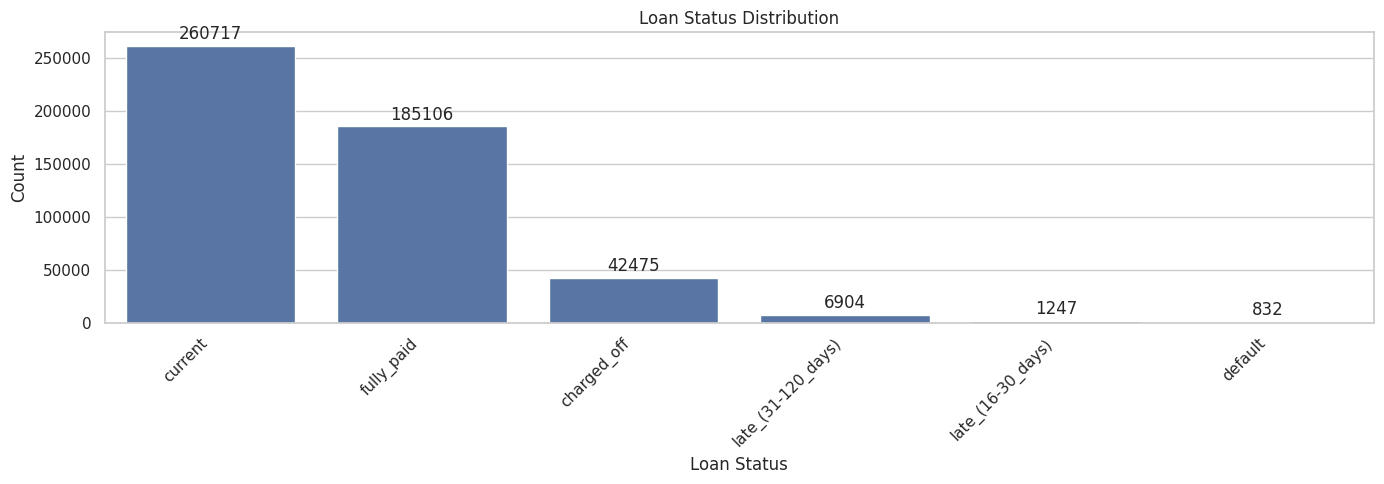

In [17]:
# Loan status distribution
counts = df['loan_status'].value_counts()

plt.figure(figsize=(14, 5))
ax = sns.countplot(data=df, x='loan_status', order=counts.index)
ax.set_title('Loan Status Distribution')
ax.set_xlabel('Loan Status')
ax.set_ylabel('Count')
ax.bar_label(ax.containers[0], padding=2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

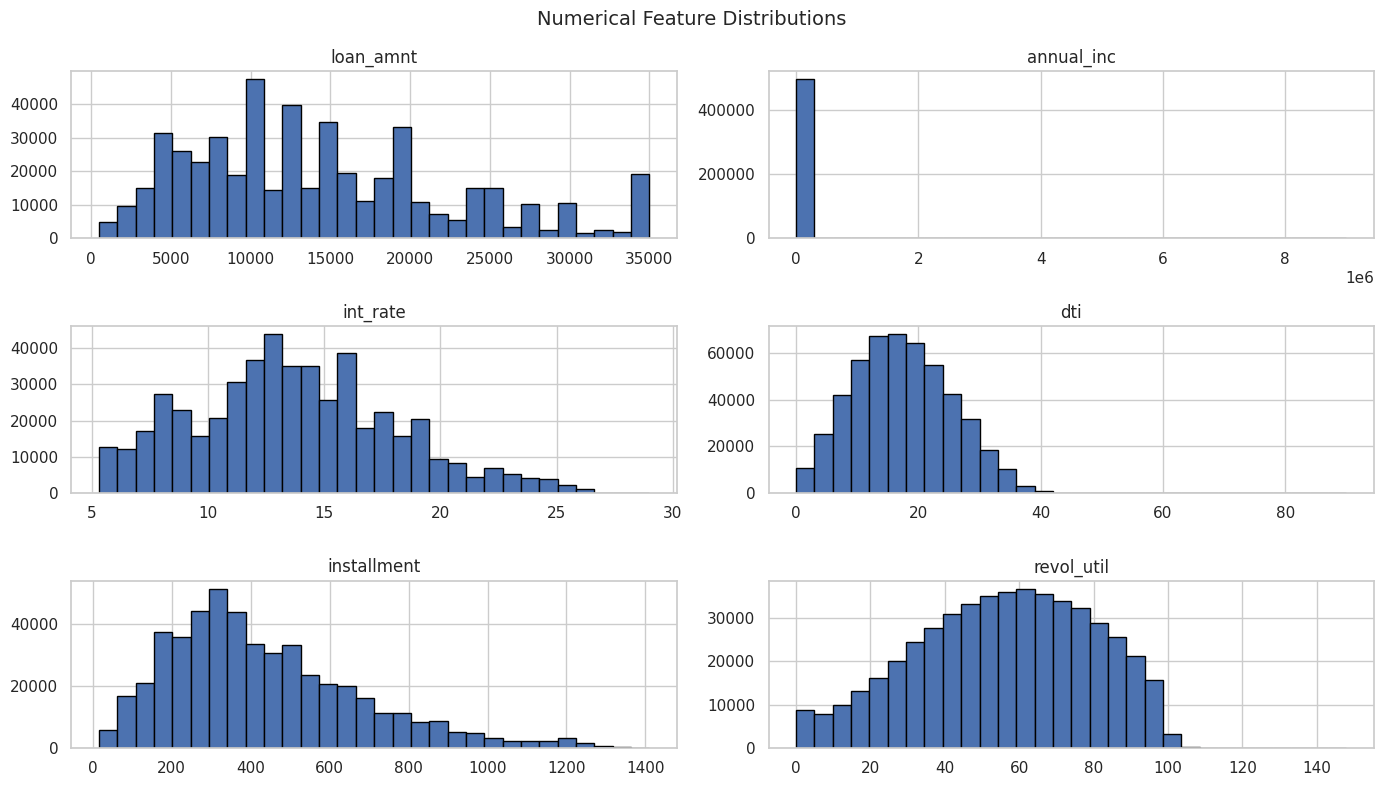

In [18]:
# Numerical variable distributions
num_features_plot = ['loan_amnt', 'annual_inc', 'int_rate', 'dti', 'installment', 'revol_util']

df[num_features_plot].hist(bins=30, figsize=(14, 8), edgecolor='black')
plt.suptitle('Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

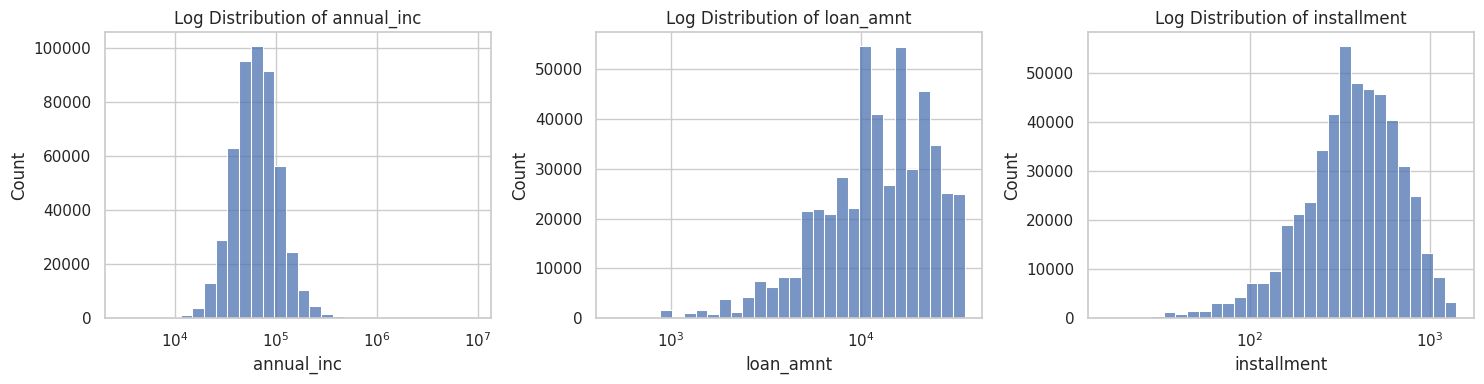

In [19]:
# Log-scaled distributions for skewed variables
skewed = ['annual_inc', 'loan_amnt', 'installment']

plt.figure(figsize=(15, 4))
for i, col in enumerate(skewed, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=30, log_scale=True)
    plt.title(f'Log Distribution of {col}')
plt.tight_layout()
plt.show()

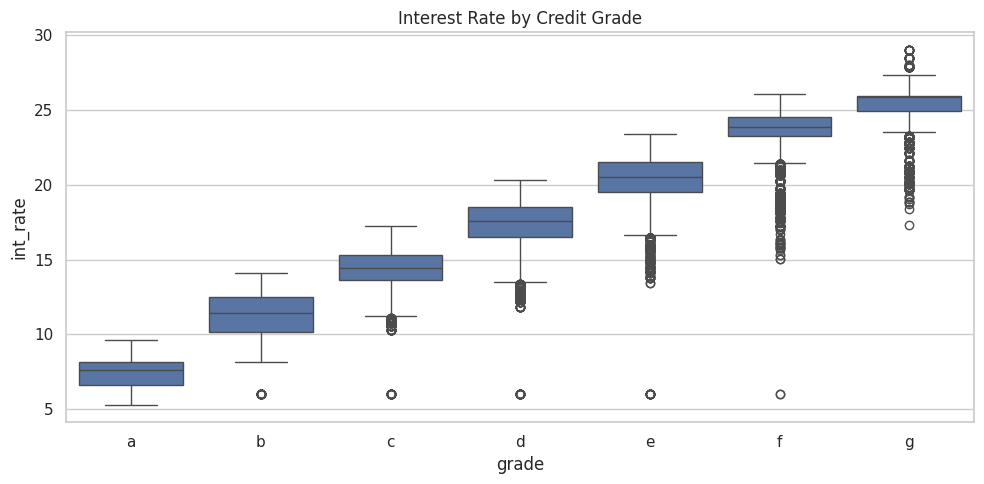

In [20]:
# Interest rate by grade
if 'grade' in df.columns:
    plt.figure(figsize=(10, 5))
    grade_order = sorted(df['grade'].dropna().unique())
    sns.boxplot(data=df, x='grade', y='int_rate', order=grade_order)
    plt.title('Interest Rate by Credit Grade')
    plt.tight_layout()
    plt.show()

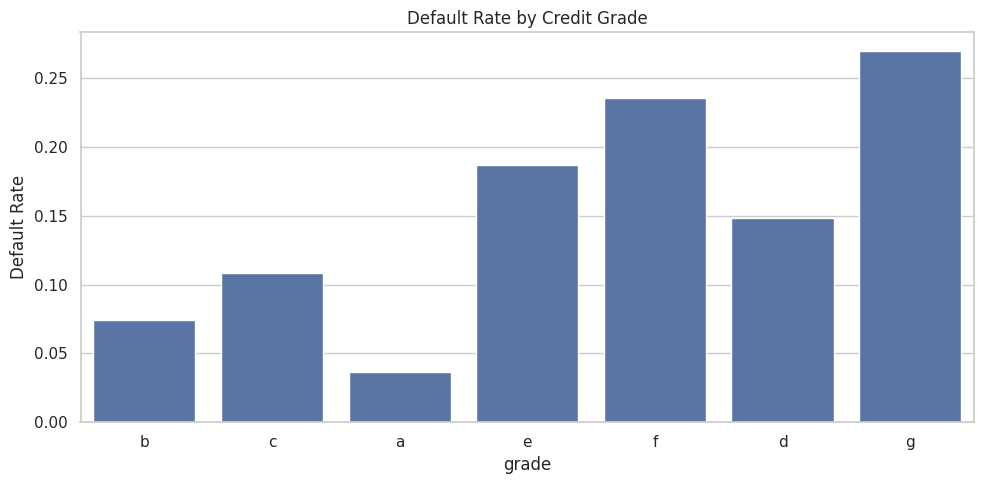

In [21]:
# Default rate by grade
if 'grade' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x='grade', y='default_flag', estimator='mean', errorbar=None)
    plt.title('Default Rate by Credit Grade')
    plt.ylabel('Default Rate')
    plt.tight_layout()
    plt.show()

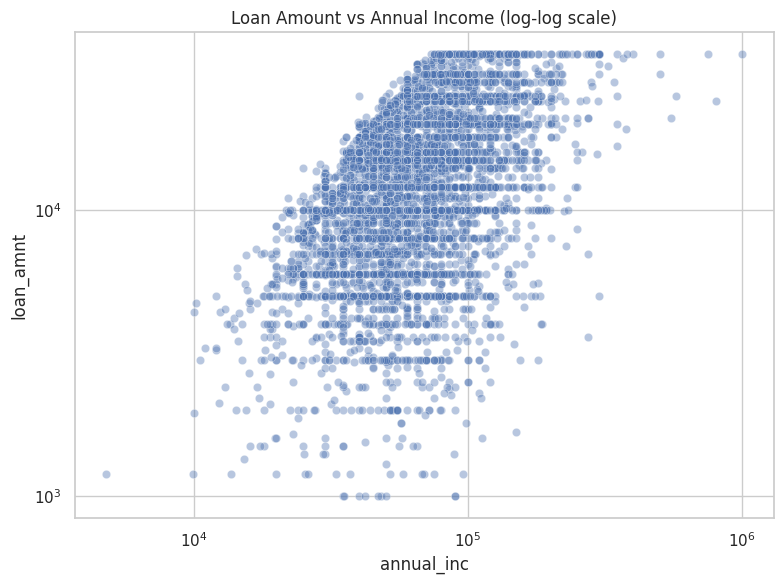

In [22]:
# Loan amount vs annual income
sample_df = df.sample(min(5000, len(df)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample_df, x='annual_inc', y='loan_amnt', alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.title('Loan Amount vs Annual Income (log-log scale)')
plt.tight_layout()
plt.show()

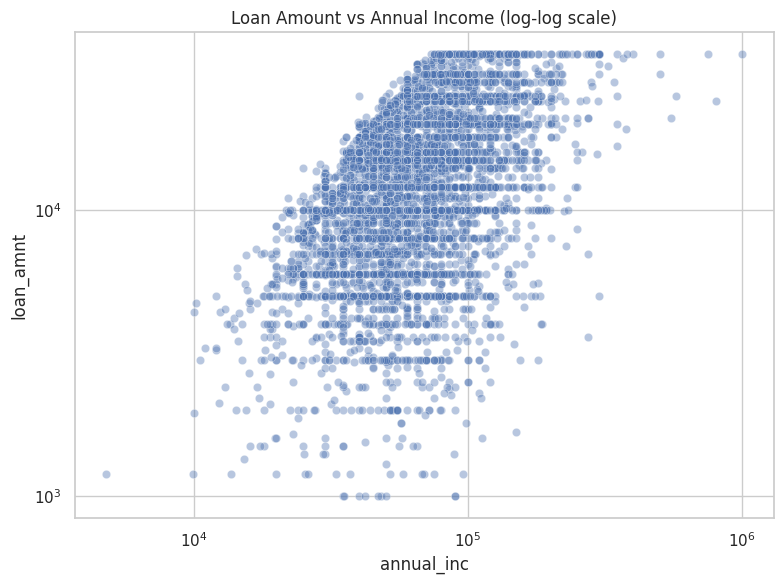

In [23]:
# Loan amount vs annual income
sample_df = df.sample(min(5000, len(df)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample_df, x='annual_inc', y='loan_amnt', alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.title('Loan Amount vs Annual Income (log-log scale)')
plt.tight_layout()
plt.show()

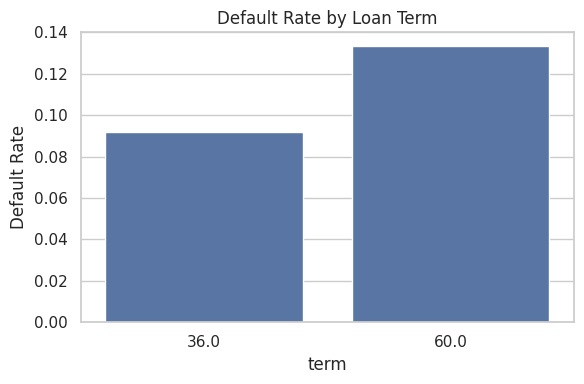

In [25]:
# Term impact on default
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='term', y='default_flag', estimator='mean', errorbar=None)
plt.title('Default Rate by Loan Term')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

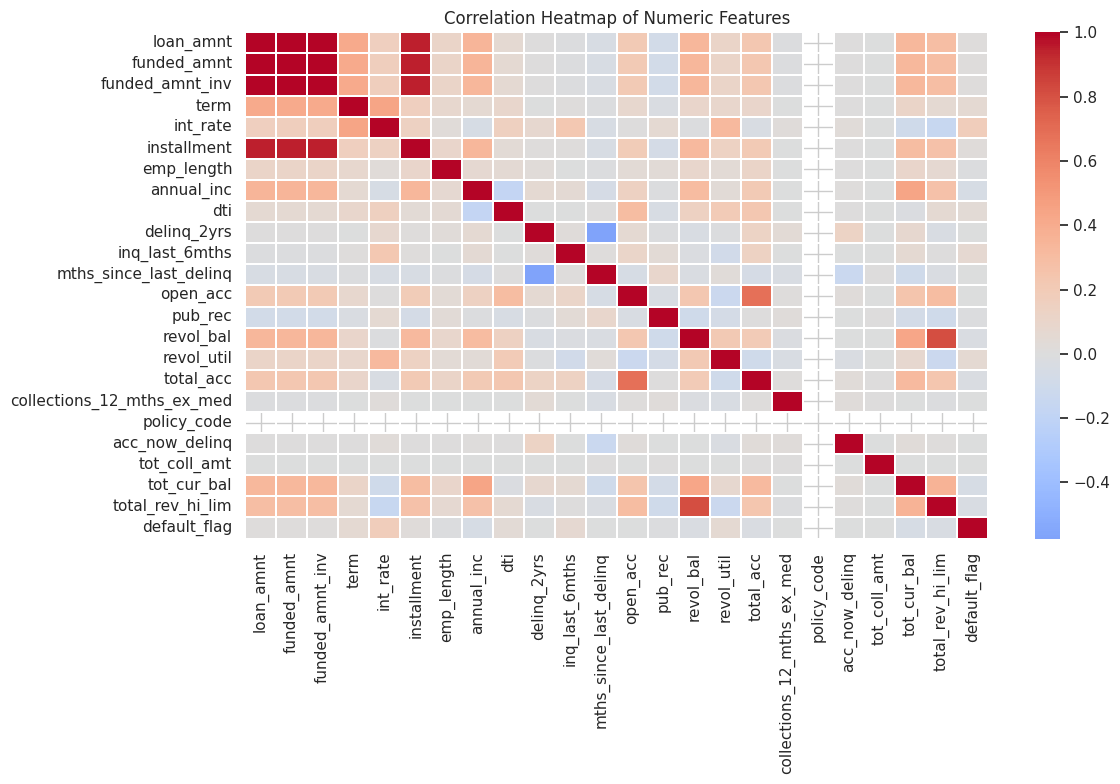

In [26]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## EDA Summary

Initial exploratory analysis suggests that default risk is higher among borrowers with:
- higher interest rates
- higher debt burden
- weaker credit quality
- longer loan terms
- prior delinquency history

These findings are economically intuitive and support the use of both traditional statistical models and more flexible machine learning methods.

# 7. Feature Engineering

This section creates risk-oriented features designed to improve predictive performance and interpretability.

In [27]:
# Credit history length
df['credit_history_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25

# Remove impossible values
df = df[df['credit_history_years'] > 0].copy()

# Affordability / leverage features
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc']
df['payment_to_income'] = (df['installment'] * 12) / df['annual_inc']
df['revol_bal_to_income'] = df['revol_bal'] / df['annual_inc']

# Utilization / delinquency flags
df['high_revol_util'] = (df['revol_util'] > 75).astype(int)
df['prior_delinquency'] = ((df['delinq_2yrs'] > 0) | (df['pub_rec'] > 0)).astype(int)

# Loan term flag
df['long_term'] = (df['term'] == 60).astype(int)

print("Feature engineering complete.")

Feature engineering complete.


In [28]:
engineered_features = [
    'loan_to_income',
    'payment_to_income',
    'credit_history_years',
    'revol_bal_to_income',
    'high_revol_util',
    'prior_delinquency',
    'long_term'
]

df[engineered_features + ['default_flag']].corr()['default_flag'].sort_values(ascending=False)

,default_flag
default_flag,1.000000
payment_to_income,0.085947
loan_to_income,0.079800
long_term,0.061074
high_revol_util,0.040912
revol_bal_to_income,0.018285
prior_delinquency,-0.007287
credit_history_years,-0.047200


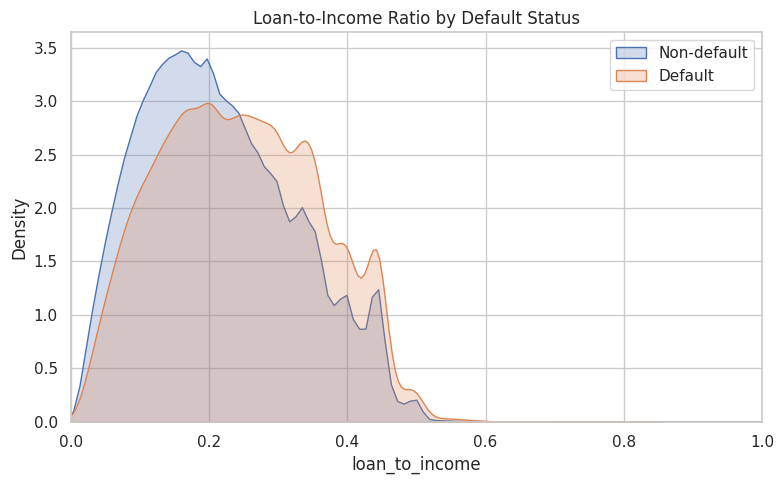

In [29]:
# Engineered feature distributions vs target
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df[df['default_flag'] == 0], x='loan_to_income', label='Non-default', fill=True)
sns.kdeplot(data=df[df['default_flag'] == 1], x='loan_to_income', label='Default', fill=True)
plt.xlim(0, 1)
plt.title('Loan-to-Income Ratio by Default Status')
plt.legend()
plt.tight_layout()
plt.show()

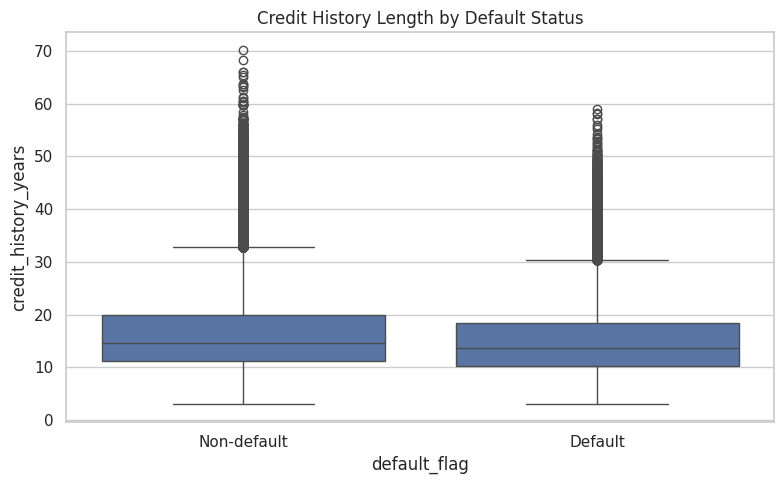

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='default_flag', y='credit_history_years')
plt.xticks([0, 1], ['Non-default', 'Default'])
plt.title('Credit History Length by Default Status')
plt.tight_layout()
plt.show()

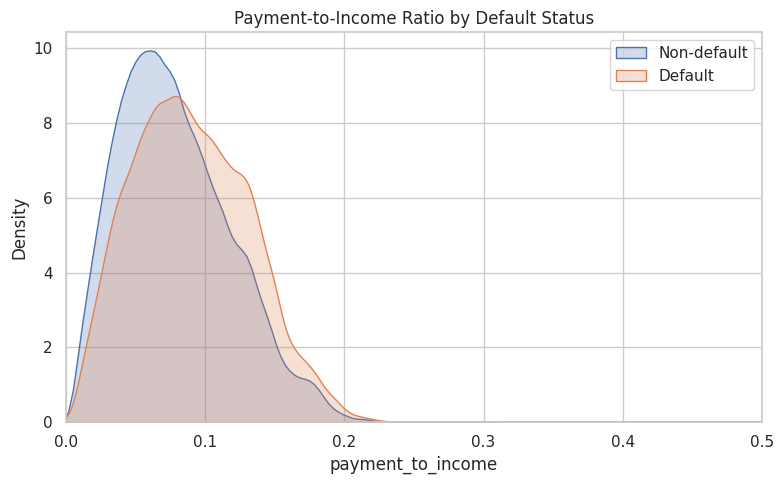

In [31]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df[df['default_flag'] == 0], x='payment_to_income', label='Non-default', fill=True)
sns.kdeplot(data=df[df['default_flag'] == 1], x='payment_to_income', label='Default', fill=True)
plt.xlim(0, 0.5)
plt.title('Payment-to-Income Ratio by Default Status')
plt.legend()
plt.tight_layout()
plt.show()

# 8. Feature Selection Strategy

The project uses a structured feature set based on:
- domain relevance
- interpretability
- leakage avoidance
- multicollinearity review
- pipeline-based feature selection for selected models

In [32]:
candidate_features = [
    # Loan characteristics
    'loan_amnt',
    'term',
    'int_rate',
    'installment',

    # Borrower profile
    'annual_inc',
    'emp_length',
    'home_ownership',
    'verification_status',

    # Credit behavior
    'dti',
    'delinq_2yrs',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'open_acc',

    # Engineered
    'loan_to_income',
    'payment_to_income',
    'credit_history_years',
    'revol_bal_to_income',
    'high_revol_util',
    'prior_delinquency',
    'long_term'
]

target = 'default_flag'

In [33]:
# Remove redundant features based on interpretation and correlation logic
features_to_drop = [
    'installment',        # partly redundant with loan amount + term
    'payment_to_income',  # redundant with loan_to_income
    'term'                # represented by long_term
]

candidate_features = [f for f in candidate_features if f not in features_to_drop]
candidate_features

['loan_amnt',
 'int_rate',
 'annual_inc',
 'emp_length',
 'home_ownership',
 'verification_status',
 'dti',
 'delinq_2yrs',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'open_acc',
 'loan_to_income',
 'credit_history_years',
 'revol_bal_to_income',
 'high_revol_util',
 'prior_delinquency',
 'long_term']

In [34]:
# Split numeric and categorical features
numeric_features = [
    'loan_amnt',
    'int_rate',
    'annual_inc',
    'emp_length',
    'dti',
    'delinq_2yrs',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'open_acc',
    'loan_to_income',
    'credit_history_years',
    'revol_bal_to_income',
    'high_revol_util',
    'prior_delinquency',
    'long_term'
]

categorical_features = [
    'home_ownership',
    'verification_status'
]

# 9. Train/Test Split

A stratified train/test split is used to preserve the proportion of default and non-default loans in both datasets.

In [35]:
X = df[numeric_features + categorical_features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Train default rate:", round(y_train.mean(), 4))
print("Test default rate:", round(y_test.mean(), 4))

X_train shape: (372960, 19)
X_test shape: (124321, 19)
Train default rate: 0.1035
Test default rate: 0.1035


In [42]:
# Create a large stratified sample of the training set for CV and tuning
# This keeps runtime practical in free Colab while preserving class balance.

train_sample_size = 120000

X_train_cv = X_train.sample(
    n=min(train_sample_size, len(X_train)),
    random_state=RANDOM_STATE
)
y_train_cv = y_train.loc[X_train_cv.index]

print("Full training shape:", X_train.shape)
print("Sampled CV/training shape:", X_train_cv.shape)
print("Full training default rate:", round(y_train.mean(), 4))
print("Sampled training default rate:", round(y_train_cv.mean(), 4))

Full training shape: (372960, 19)
Sampled CV/training shape: (120000, 19)
Full training default rate: 0.1035
Sampled training default rate: 0.1038


# 10. Preprocessing Pipelines

The modeling workflow uses:
- median imputation for numeric variables
- standardization for linear models
- one-hot encoding for categorical features
- optional feature selection
- optional SMOTE resampling for imbalanced data

In [43]:
numeric_transformer_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_transformer_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', numeric_transformer_scaled, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor_unscaled = ColumnTransformer(transformers=[
    ('num', numeric_transformer_unscaled, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# 11. Baseline and Candidate Models

To balance interpretability and predictive power, this project tests:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

Because defaults are relatively rare, recall is emphasized throughout model selection.

In [44]:
# Custom scoring dictionary
scoring = {
    'recall': make_scorer(recall_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'f1': make_scorer(f1_score),
    'roc_auc': 'roc_auc',
    'accuracy': make_scorer(accuracy_score)
}

# Lighter CV for Colab runtime
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [45]:
# Candidate model pipelines (runtime-optimized for Colab)

logistic_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=20)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', XGBClassifier(
        n_estimators=120,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lgbm_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LGBMClassifier(
        n_estimators=120,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=-1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced',
        verbose=-1
    ))
])

model_dict = {
    'Logistic Regression': logistic_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline,
    'LightGBM': lgbm_pipeline
}

# 12. Cross-Validated Baseline Comparison

This step compares candidate models using 3-fold stratified cross-validation on the training data.

In [46]:
cv_results = []

for model_name, model_pipeline in model_dict.items():
    print(f"Running CV for: {model_name}")

    scores = cross_validate(
        model_pipeline,
        X_train_cv,
        y_train_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        'model': model_name,
        'recall_cv_mean': scores['test_recall'].mean(),
        'precision_cv_mean': scores['test_precision'].mean(),
        'f1_cv_mean': scores['test_f1'].mean(),
        'roc_auc_cv_mean': scores['test_roc_auc'].mean(),
        'accuracy_cv_mean': scores['test_accuracy'].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by='recall_cv_mean',
    ascending=False
).reset_index(drop=True)

cv_results_df

Running CV for: Logistic Regression
Running CV for: Random Forest
Running CV for: XGBoost
Running CV for: LightGBM


,model,recall_cv_mean,precision_cv_mean,f1_cv_mean,roc_auc_cv_mean,accuracy_cv_mean
0,Logistic Regression,0.626998,0.167364,0.264204,0.680141,0.637583
1,Random Forest,0.002891,0.172215,0.005661,0.663015,0.894883
2,LightGBM,0.000402,0.522222,0.000802,0.687277,0.896225
3,XGBoost,0.000080,0.166667,0.000161,0.677490,0.896208


In [47]:
top_models_to_tune = cv_results_df['model'].head(3).tolist()
print("Top models selected for tuning:", top_models_to_tune)

Top models selected for tuning: ['Logistic Regression', 'Random Forest', 'LightGBM']


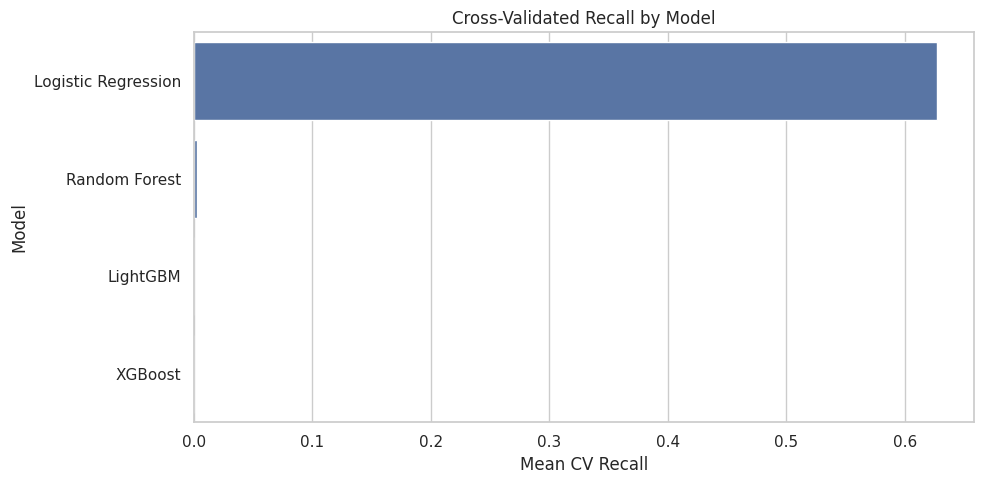

In [48]:
plt.figure(figsize=(10, 5))
sns.barplot(data=cv_results_df, x='recall_cv_mean', y='model')
plt.title('Cross-Validated Recall by Model')
plt.xlabel('Mean CV Recall')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

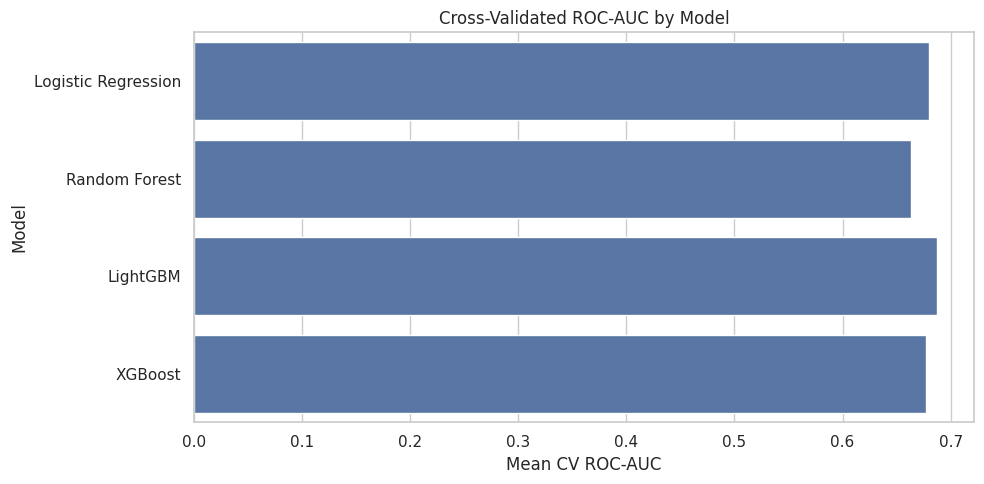

In [49]:
plt.figure(figsize=(10, 5))
sns.barplot(data=cv_results_df, x='roc_auc_cv_mean', y='model')
plt.title('Cross-Validated ROC-AUC by Model')
plt.xlabel('Mean CV ROC-AUC')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

## Interim Modeling Interpretation

At this stage, the goal is not yet to declare a final winner, but to identify the strongest candidate models for deeper tuning and later evaluation.

Because the business objective prioritizes identifying risky borrowers, models with stronger recall are especially important. However, recall must be considered alongside ROC-AUC, precision, and F1-score to avoid selecting a model that overpredicts default excessively.

# 13. Hyperparameter Tuning

To improve model performance, this project uses a two-stage tuning strategy:

1. **RandomizedSearchCV** to explore a broader parameter space efficiently
2. **GridSearchCV** to refine the best candidate settings

The tuning objective is **recall**.

# 13. Hyperparameter Tuning

To improve model performance, this project uses a two-stage tuning strategy:

1. **RandomizedSearchCV** to explore a broader parameter space efficiently
2. **GridSearchCV** to refine the best candidate settings

The tuning objective is **recall**.

## 13.1 Tune Logistic Regression

In [50]:
if 'Logistic Regression' in top_models_to_tune:
    logistic_random_params = {
        'feature_selection__k': [10, 15, 20, 'all'],
        'classifier__C': loguniform(1e-3, 10),
        'classifier__penalty': ['l1', 'l2']
    }

    logistic_random_search = RandomizedSearchCV(
        estimator=logistic_pipeline,
        param_distributions=logistic_random_params,
        n_iter=6,
        scoring='recall',
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    logistic_random_search.fit(X_train_cv, y_train_cv)

    print("Best logistic randomized recall:", logistic_random_search.best_score_)
    print("Best logistic params:", logistic_random_search.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best logistic randomized recall: 0.6286838512808158
Best logistic params: {'classifier__C': np.float64(0.004207988669606638), 'classifier__penalty': 'l1', 'feature_selection__k': 20}


In [51]:
if 'Logistic Regression' in top_models_to_tune:
    best_logistic_params = logistic_random_search.best_params_

    logistic_grid_params = {
        'feature_selection__k': [best_logistic_params['feature_selection__k']],
        'classifier__C': [
            best_logistic_params['classifier__C'] * 0.75,
            best_logistic_params['classifier__C'],
            best_logistic_params['classifier__C'] * 1.25
        ],
        'classifier__penalty': [best_logistic_params['classifier__penalty']]
    }

    logistic_grid_search = GridSearchCV(
        estimator=logistic_pipeline,
        param_grid=logistic_grid_params,
        scoring='recall',
        cv=cv,
        verbose=1,
        n_jobs=-1
    )

    logistic_grid_search.fit(X_train_cv, y_train_cv)

    print("Best tuned logistic recall:", logistic_grid_search.best_score_)
    print("Best tuned logistic params:", logistic_grid_search.best_params_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best tuned logistic recall: 0.6295671725688589
Best tuned logistic params: {'classifier__C': np.float64(0.0031559915022049785), 'classifier__penalty': 'l1', 'feature_selection__k': 20}


## 13.2 Tune Random Forest

In [52]:
if 'Random Forest' in top_models_to_tune:
    rf_random_params = {
        'classifier__n_estimators': [80, 120, 160],
        'classifier__max_depth': [8, 12, 16],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt', 'log2']
    }

    rf_random_search = RandomizedSearchCV(
        estimator=rf_pipeline,
        param_distributions=rf_random_params,
        n_iter=6,
        scoring='recall',
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    rf_random_search.fit(X_train_cv, y_train_cv)

    print("Best RF randomized recall:", rf_random_search.best_score_)
    print("Best RF params:", rf_random_search.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best RF randomized recall: 0.030916245081506463
Best RF params: {'classifier__n_estimators': 120, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 8}


In [53]:
if 'Random Forest' in top_models_to_tune:
    best_rf_params = rf_random_search.best_params_

    rf_grid_params = {
        'classifier__n_estimators': [best_rf_params['classifier__n_estimators']],
        'classifier__max_depth': [best_rf_params['classifier__max_depth']],
        'classifier__min_samples_split': [best_rf_params['classifier__min_samples_split']],
        'classifier__min_samples_leaf': [
            best_rf_params['classifier__min_samples_leaf'],
            min(best_rf_params['classifier__min_samples_leaf'] + 1, 4)
        ],
        'classifier__max_features': [best_rf_params['classifier__max_features']]
    }

    rf_grid_search = GridSearchCV(
        estimator=rf_pipeline,
        param_grid=rf_grid_params,
        scoring='recall',
        cv=cv,
        verbose=1,
        n_jobs=-1
    )

    rf_grid_search.fit(X_train_cv, y_train_cv)

    print("Best tuned RF recall:", rf_grid_search.best_score_)
    print("Best tuned RF params:", rf_grid_search.best_params_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best tuned RF recall: 0.030916245081506463
Best tuned RF params: {'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 120}


## 13.3 Tune XGBoost

In [54]:
if 'XGBoost' in top_models_to_tune:
    xgb_random_params = {
        'classifier__n_estimators': [80, 120, 160],
        'classifier__max_depth': [3, 4, 5],
        'classifier__learning_rate': [0.03, 0.05, 0.1],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }

    xgb_random_search = RandomizedSearchCV(
        estimator=xgb_pipeline,
        param_distributions=xgb_random_params,
        n_iter=6,
        scoring='recall',
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    xgb_random_search.fit(X_train_cv, y_train_cv)

    print("Best XGBoost randomized recall:", xgb_random_search.best_score_)
    print("Best XGBoost params:", xgb_random_search.best_params_)

In [55]:
if 'XGBoost' in top_models_to_tune:
    best_xgb_params = xgb_random_search.best_params_

    xgb_grid_params = {
        'classifier__n_estimators': [best_xgb_params['classifier__n_estimators']],
        'classifier__max_depth': [best_xgb_params['classifier__max_depth']],
        'classifier__learning_rate': [
            max(0.01, best_xgb_params['classifier__learning_rate'] * 0.8),
            best_xgb_params['classifier__learning_rate']
        ],
        'classifier__subsample': [best_xgb_params['classifier__subsample']],
        'classifier__colsample_bytree': [best_xgb_params['classifier__colsample_bytree']]
    }

    xgb_grid_search = GridSearchCV(
        estimator=xgb_pipeline,
        param_grid=xgb_grid_params,
        scoring='recall',
        cv=cv,
        verbose=1,
        n_jobs=-1
    )

    xgb_grid_search.fit(X_train_cv, y_train_cv)

    print("Best tuned XGBoost recall:", xgb_grid_search.best_score_)
    print("Best tuned XGBoost params:", xgb_grid_search.best_params_)

## 13.4 Tune LightGBM

In [56]:
if 'LightGBM' in top_models_to_tune:
    lgbm_random_params = {
        'classifier__n_estimators': [80, 120, 160],
        'classifier__learning_rate': [0.03, 0.05, 0.1],
        'classifier__num_leaves': [15, 31, 63],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }

    lgbm_random_search = RandomizedSearchCV(
        estimator=lgbm_pipeline,
        param_distributions=lgbm_random_params,
        n_iter=6,
        scoring='recall',
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    lgbm_random_search.fit(X_train_cv, y_train_cv)

    print("Best LightGBM randomized recall:", lgbm_random_search.best_score_)
    print("Best LightGBM params:", lgbm_random_search.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best LightGBM randomized recall: 0.0
Best LightGBM params: {'classifier__subsample': 1.0, 'classifier__num_leaves': 63, 'classifier__n_estimators': 80, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 1.0}


In [57]:
if 'LightGBM' in top_models_to_tune:
    best_lgbm_params = lgbm_random_search.best_params_

    lgbm_grid_params = {
        'classifier__n_estimators': [best_lgbm_params['classifier__n_estimators']],
        'classifier__learning_rate': [
            max(0.01, best_lgbm_params['classifier__learning_rate'] * 0.8),
            best_lgbm_params['classifier__learning_rate']
        ],
        'classifier__num_leaves': [best_lgbm_params['classifier__num_leaves']],
        'classifier__subsample': [best_lgbm_params['classifier__subsample']],
        'classifier__colsample_bytree': [best_lgbm_params['classifier__colsample_bytree']]
    }

    lgbm_grid_search = GridSearchCV(
        estimator=lgbm_pipeline,
        param_grid=lgbm_grid_params,
        scoring='recall',
        cv=cv,
        verbose=1,
        n_jobs=-1
    )

    lgbm_grid_search.fit(X_train_cv, y_train_cv)

    print("Best tuned LightGBM recall:", lgbm_grid_search.best_score_)
    print("Best tuned LightGBM params:", lgbm_grid_search.best_params_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best tuned LightGBM recall: 0.0
Best tuned LightGBM params: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.04000000000000001, 'classifier__n_estimators': 80, 'classifier__num_leaves': 63, 'classifier__subsample': 1.0}


# 14. Compare Tuned Models

In [58]:
tuned_models = {}

if 'Logistic Regression' in top_models_to_tune:
    tuned_models['Logistic Regression (Tuned)'] = logistic_grid_search.best_estimator_

if 'Random Forest' in top_models_to_tune:
    tuned_models['Random Forest (Tuned)'] = rf_grid_search.best_estimator_

if 'XGBoost' in top_models_to_tune:
    tuned_models['XGBoost (Tuned)'] = xgb_grid_search.best_estimator_

if 'LightGBM' in top_models_to_tune:
    tuned_models['LightGBM (Tuned)'] = lgbm_grid_search.best_estimator_

print("Tuned models:", list(tuned_models.keys()))

tuned_cv_results = []

for model_name, tuned_model in tuned_models.items():
    print(f"Running tuned CV for: {model_name}")

    scores = cross_validate(
        tuned_model,
        X_train_cv,
        y_train_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    tuned_cv_results.append({
        'model': model_name,
        'recall_cv_mean': scores['test_recall'].mean(),
        'precision_cv_mean': scores['test_precision'].mean(),
        'f1_cv_mean': scores['test_f1'].mean(),
        'roc_auc_cv_mean': scores['test_roc_auc'].mean(),
        'accuracy_cv_mean': scores['test_accuracy'].mean()
    })

tuned_cv_results_df = pd.DataFrame(tuned_cv_results).sort_values(
    by='recall_cv_mean',
    ascending=False
).reset_index(drop=True)

tuned_cv_results_df

Tuned models: ['Logistic Regression (Tuned)', 'Random Forest (Tuned)', 'LightGBM (Tuned)']
Running tuned CV for: Logistic Regression (Tuned)
Running tuned CV for: Random Forest (Tuned)
Running tuned CV for: LightGBM (Tuned)


,model,recall_cv_mean,precision_cv_mean,f1_cv_mean,roc_auc_cv_mean,accuracy_cv_mean
0,Logistic Regression (Tuned),0.630772,0.166163,0.263034,0.680494,0.633200
1,Random Forest (Tuned),0.030916,0.214605,0.053393,0.647800,0.887467
2,LightGBM (Tuned),0.000000,0.000000,0.000000,0.679550,0.896217


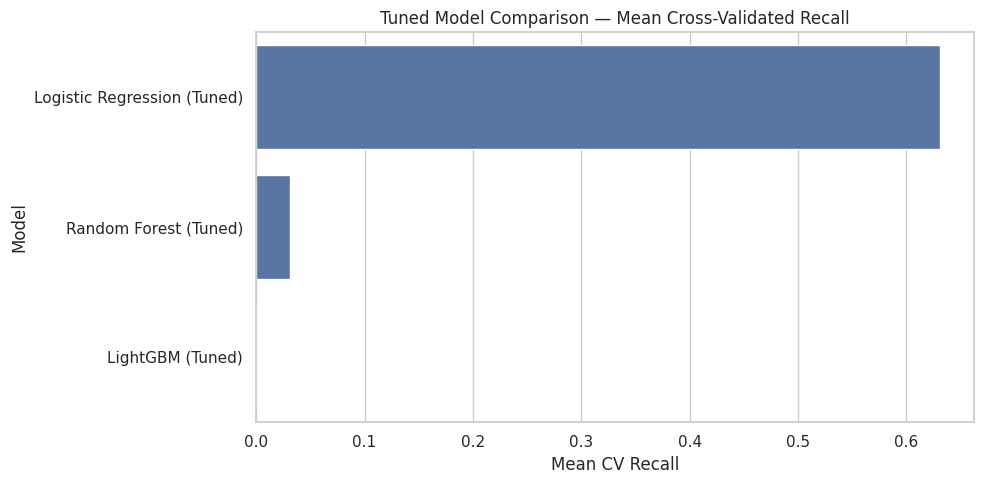

In [59]:
plt.figure(figsize=(10, 5))
sns.barplot(data=tuned_cv_results_df, x='recall_cv_mean', y='model')
plt.title('Tuned Model Comparison — Mean Cross-Validated Recall')
plt.xlabel('Mean CV Recall')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

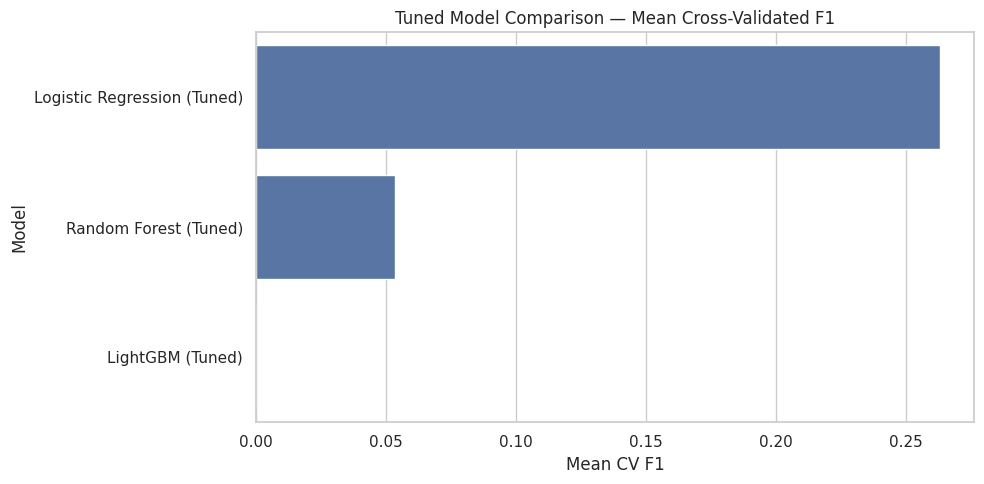

In [60]:
plt.figure(figsize=(10, 5))
sns.barplot(data=tuned_cv_results_df, x='f1_cv_mean', y='model')
plt.title('Tuned Model Comparison — Mean Cross-Validated F1')
plt.xlabel('Mean CV F1')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

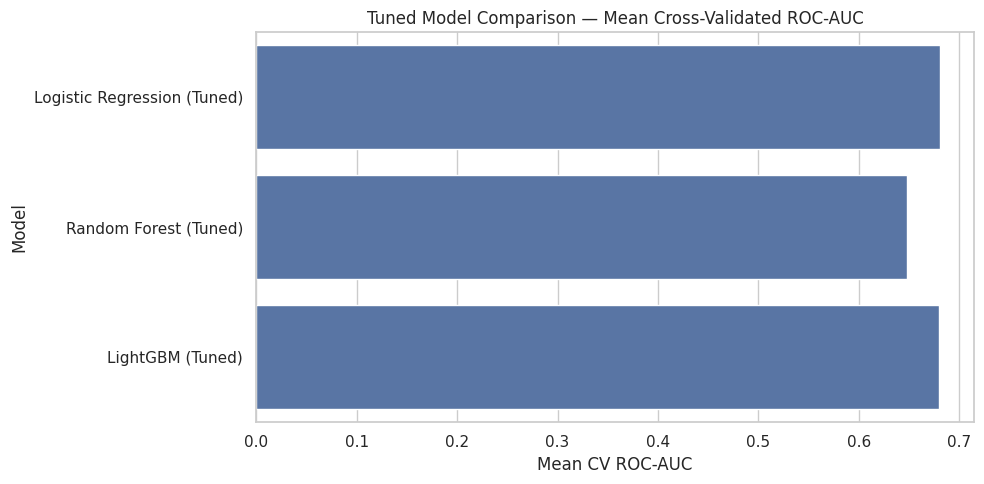

In [61]:
plt.figure(figsize=(10, 5))
sns.barplot(data=tuned_cv_results_df, x='roc_auc_cv_mean', y='model')
plt.title('Tuned Model Comparison — Mean Cross-Validated ROC-AUC')
plt.xlabel('Mean CV ROC-AUC')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# 15. Fit Tuned Models on Training Data

The tuned models are fit on the full training set so they can be evaluated in the next notebook using the holdout test set.

In [62]:
for model_name, tuned_model in tuned_models.items():
    tuned_model.fit(X_train, y_train)
    print(f"Fitted: {model_name}")

Fitted: Logistic Regression (Tuned)
Fitted: Random Forest (Tuned)
Fitted: LightGBM (Tuned)


# 16. Save Key Objects for Notebook 2

To support the evaluation notebook, this project saves:
- training and test data
- tuned models
- summary comparison table

In [63]:
import joblib
import os

output_dir = "/content/capstone_outputs"
os.makedirs(output_dir, exist_ok=True)

# Save datasets
joblib.dump(X_train, f"{output_dir}/X_train.pkl")
joblib.dump(X_test, f"{output_dir}/X_test.pkl")
joblib.dump(y_train, f"{output_dir}/y_train.pkl")
joblib.dump(y_test, f"{output_dir}/y_test.pkl")

# Save tuned models only if present
if 'Logistic Regression (Tuned)' in tuned_models:
    joblib.dump(tuned_models['Logistic Regression (Tuned)'], f"{output_dir}/logistic_tuned.pkl")

if 'Random Forest (Tuned)' in tuned_models:
    joblib.dump(tuned_models['Random Forest (Tuned)'], f"{output_dir}/rf_tuned.pkl")

if 'XGBoost (Tuned)' in tuned_models:
    joblib.dump(tuned_models['XGBoost (Tuned)'], f"{output_dir}/xgb_tuned.pkl")

if 'LightGBM (Tuned)' in tuned_models:
    joblib.dump(tuned_models['LightGBM (Tuned)'], f"{output_dir}/lgbm_tuned.pkl")

# Save result tables
cv_results_df.to_csv(f"{output_dir}/baseline_cv_results.csv", index=False)
tuned_cv_results_df.to_csv(f"{output_dir}/tuned_cv_results.csv", index=False)

print("Saved all modeling outputs to:", output_dir)

Saved all modeling outputs to: /content/capstone_outputs


# 17. Modeling Conclusions

## Key Takeaways

- The dataset contains meaningful predictive signal for loan default risk.
- Exploratory analysis and engineered features revealed intuitive relationships between borrower characteristics, debt burden, pricing, and default behavior.
- Multiple models were tested to balance interpretability and predictive performance, including Logistic Regression, Random Forest, and LightGBM.
- Because missed defaults are costly in a lending context, model selection emphasized **recall** as the primary evaluation metric.

## Model Performance Insights

- **Logistic Regression (Tuned)** achieved the strongest performance in terms of recall (~0.63), indicating a strong ability to identify high-risk borrowers.
- **Random Forest (Tuned)** showed very low recall (~0.03), suggesting that it failed to effectively identify default cases despite reasonable overall accuracy.
- **LightGBM (Tuned)** produced near-zero recall, indicating that it predominantly classified observations as non-default under the current configuration.

These results suggest that, for this dataset and modeling setup, simpler linear models can outperform more complex tree-based models when the objective is to maximize recall. This highlights the importance of aligning model selection with the specific business objective rather than relying solely on model complexity.

## Interpretation

- Logistic Regression demonstrates strong performance because the key drivers of default (e.g., interest rate, debt burden, delinquency history) exhibit relationships that are well captured by a linear model.
- Tree-based models may require further tuning, alternative imbalance handling, or threshold adjustments to perform competitively in a recall-focused setting.
- The results reinforce that more complex models do not automatically lead to better performance, particularly when the evaluation metric prioritizes detecting minority class events such as defaults.

## Methodological Note

Hyperparameter tuning was performed using a two-stage approach:
- **RandomizedSearchCV** to efficiently explore a broad parameter space
- **GridSearchCV** for targeted refinement around the best parameter regions

Due to computational constraints in Google Colab, tuning was performed on a large stratified sample of the training data, while final models were fit on the full training set.

## Transition to the Evaluation Notebook

The next notebook will:

- evaluate the tuned models on the holdout test set
- compare recall, precision, F1-score, and ROC-AUC
- analyze confusion matrices to understand business impact
- plot ROC and precision-recall curves
- test threshold adjustments to improve recall performance
- recommend the best model for a recall-focused credit risk use case